<a href="https://colab.research.google.com/github/MachineLearnia/Python-Machine-Learning/blob/master/19%20-%20Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 19/30 Visualisation de Données avec Seaborn

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [94]:
iris = sns.load_dataset('iris')
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


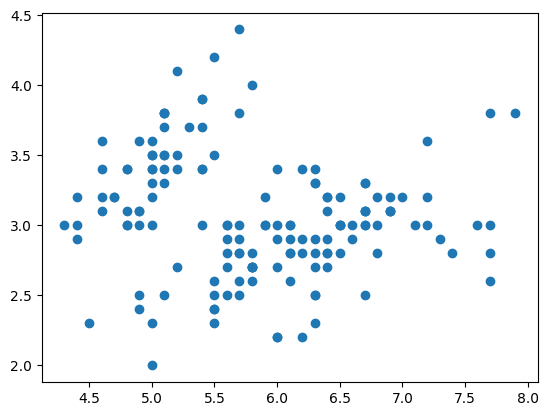

In [95]:
plt.scatter(iris['sepal_length'], iris['sepal_width'])


## 1. Pairplot() : La vue d'ensemble

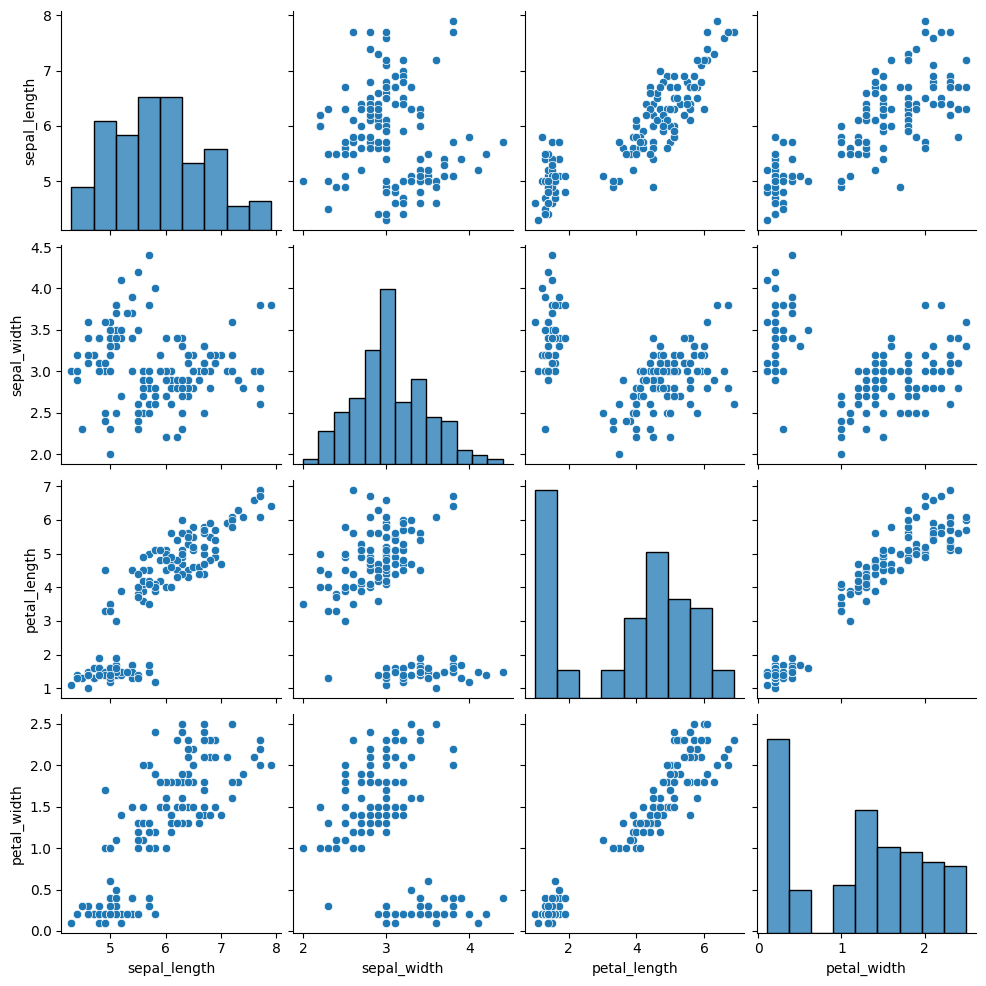

In [96]:
sns.pairplot(iris)


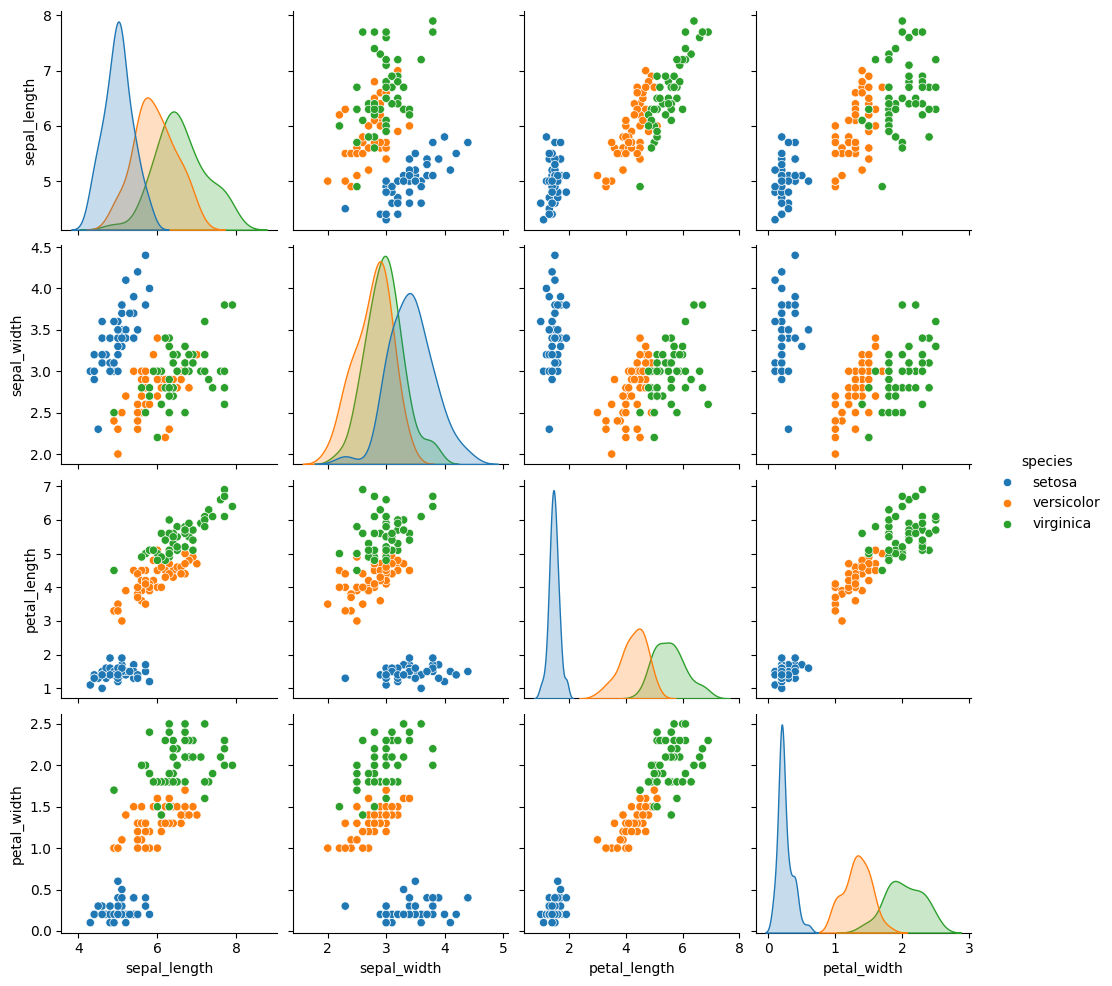

In [97]:
sns.pairplot(iris, hue='species')


## 2. Visualiser de catégories

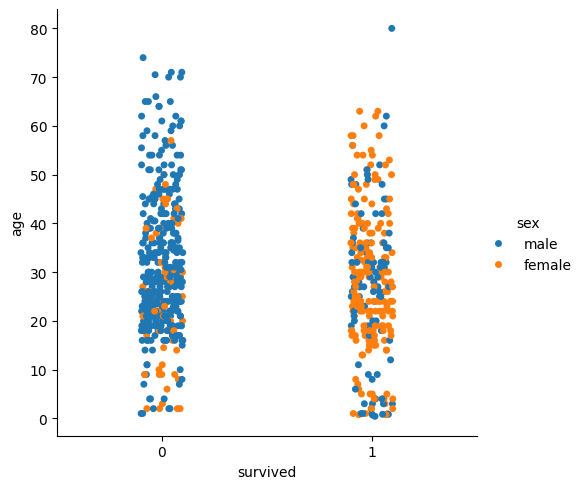

In [98]:
titanic = sns.load_dataset("titanic")
sns.catplot(x='survived', y='age', data=titanic, hue='sex')
plt.show()


In [99]:
titanic.drop(['alone', 'alive', 'who', 'adult_male', 'embark_town', 'class'], axis=1, inplace=True)
titanic.dropna(axis=0, inplace=True)
titanic.shape, titanic.head()


((182, 9),
     survived  pclass     sex   age  sibsp  parch     fare embarked deck
 1          1       1  female  38.0      1      0  71.2833        C    C
 3          1       1  female  35.0      1      0  53.1000        S    C
 6          0       1    male  54.0      0      0  51.8625        S    E
 10         1       3  female   4.0      1      1  16.7000        S    G
 11         1       1  female  58.0      0      0  26.5500        S    C)

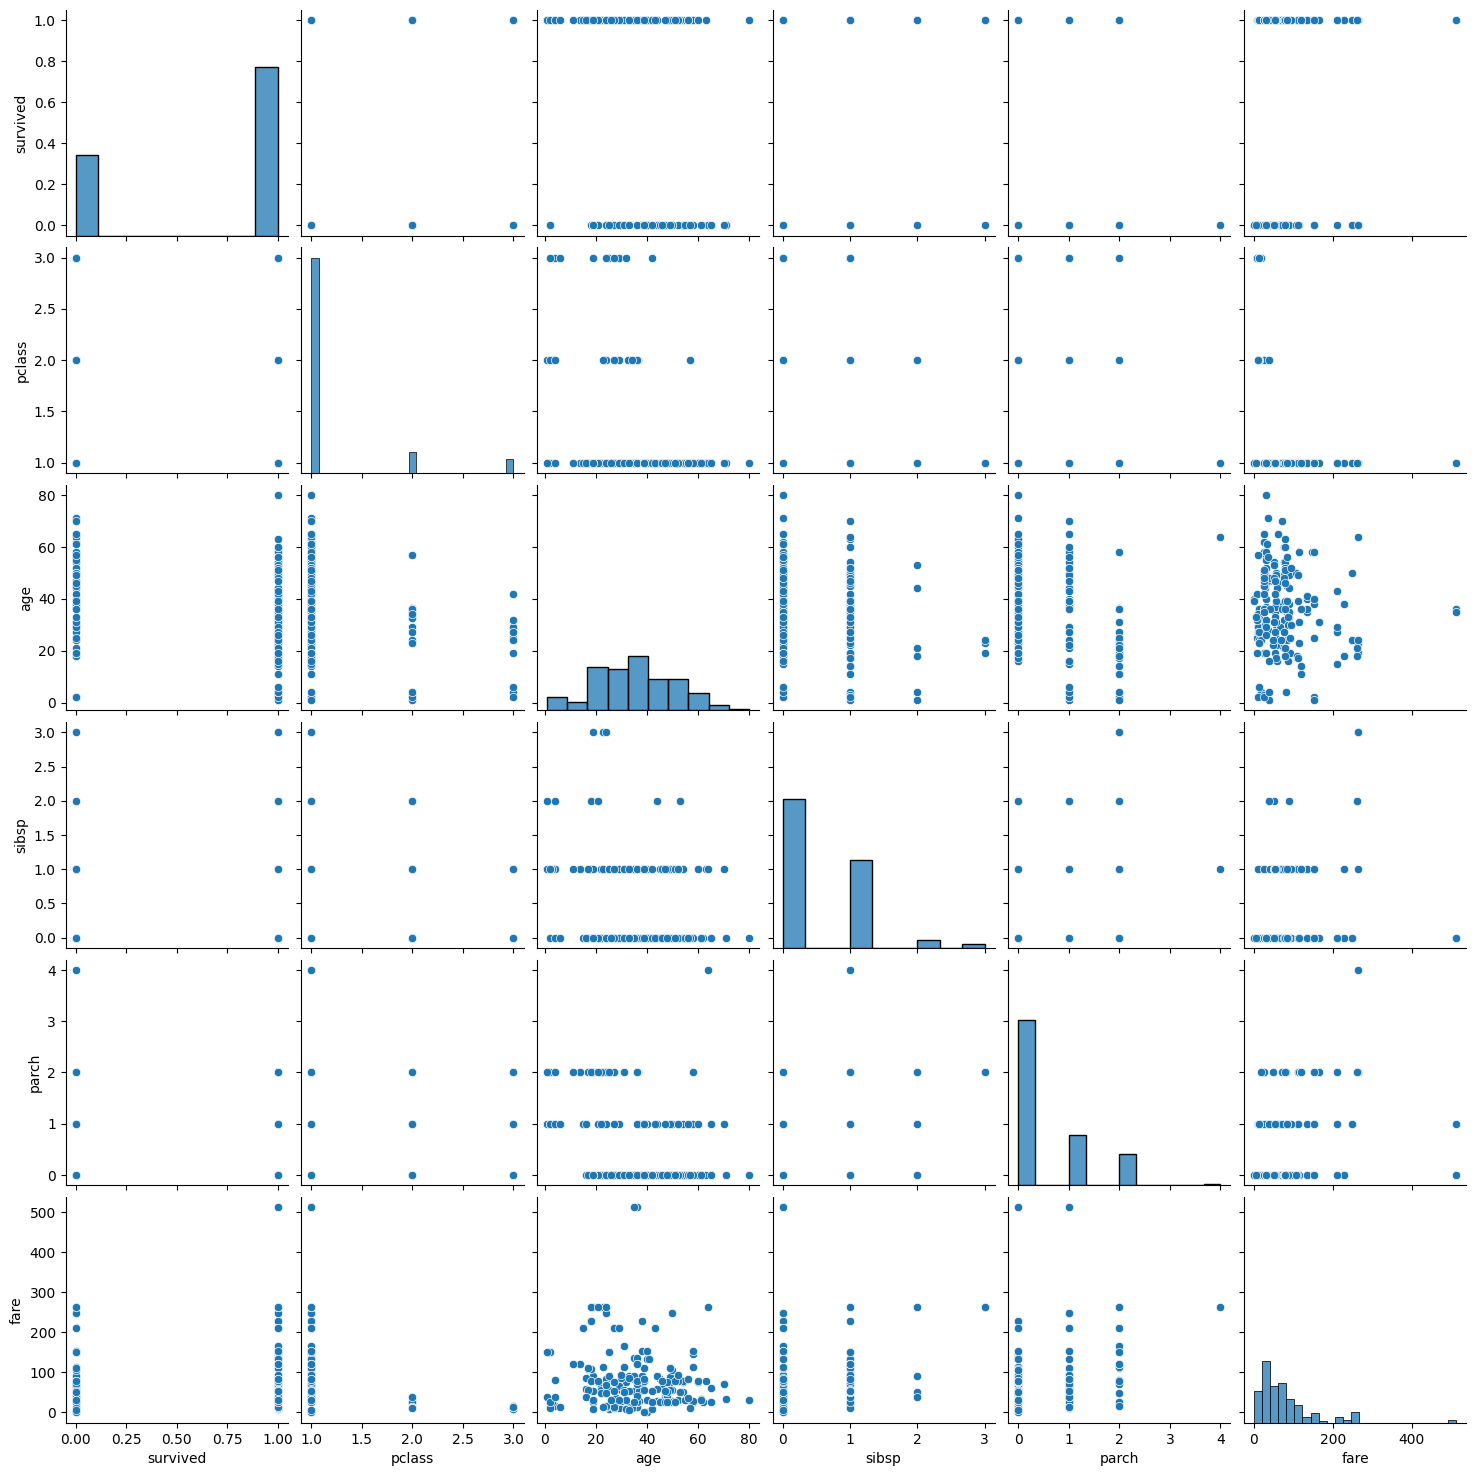

In [100]:
sns.pairplot(titanic)


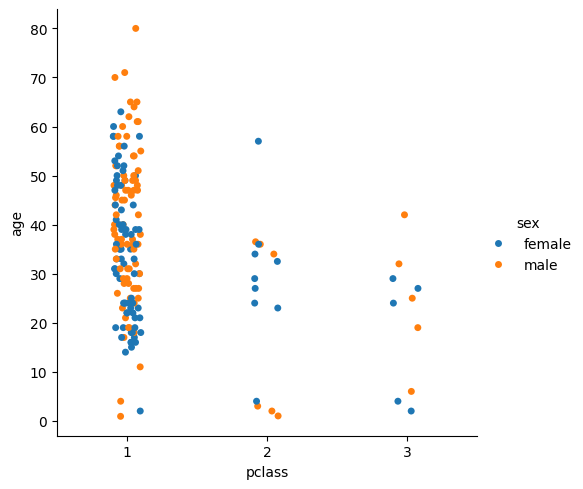

In [101]:
sns.catplot(x='pclass', y='age', data = titanic, hue='sex')


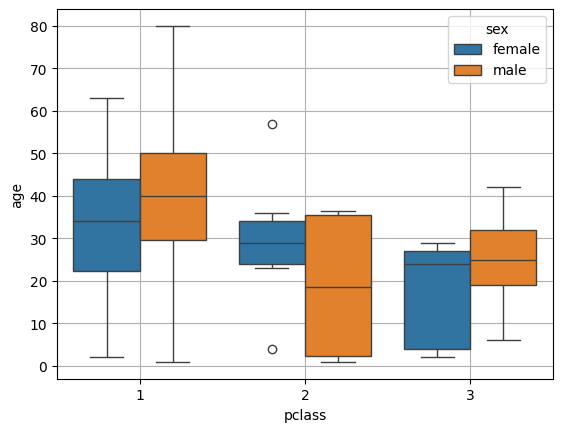

In [102]:
sns.boxplot(x='pclass', y='age', data=titanic, hue='sex')
plt.grid()
plt.show()


<Axes: xlabel='age', ylabel='fare'>

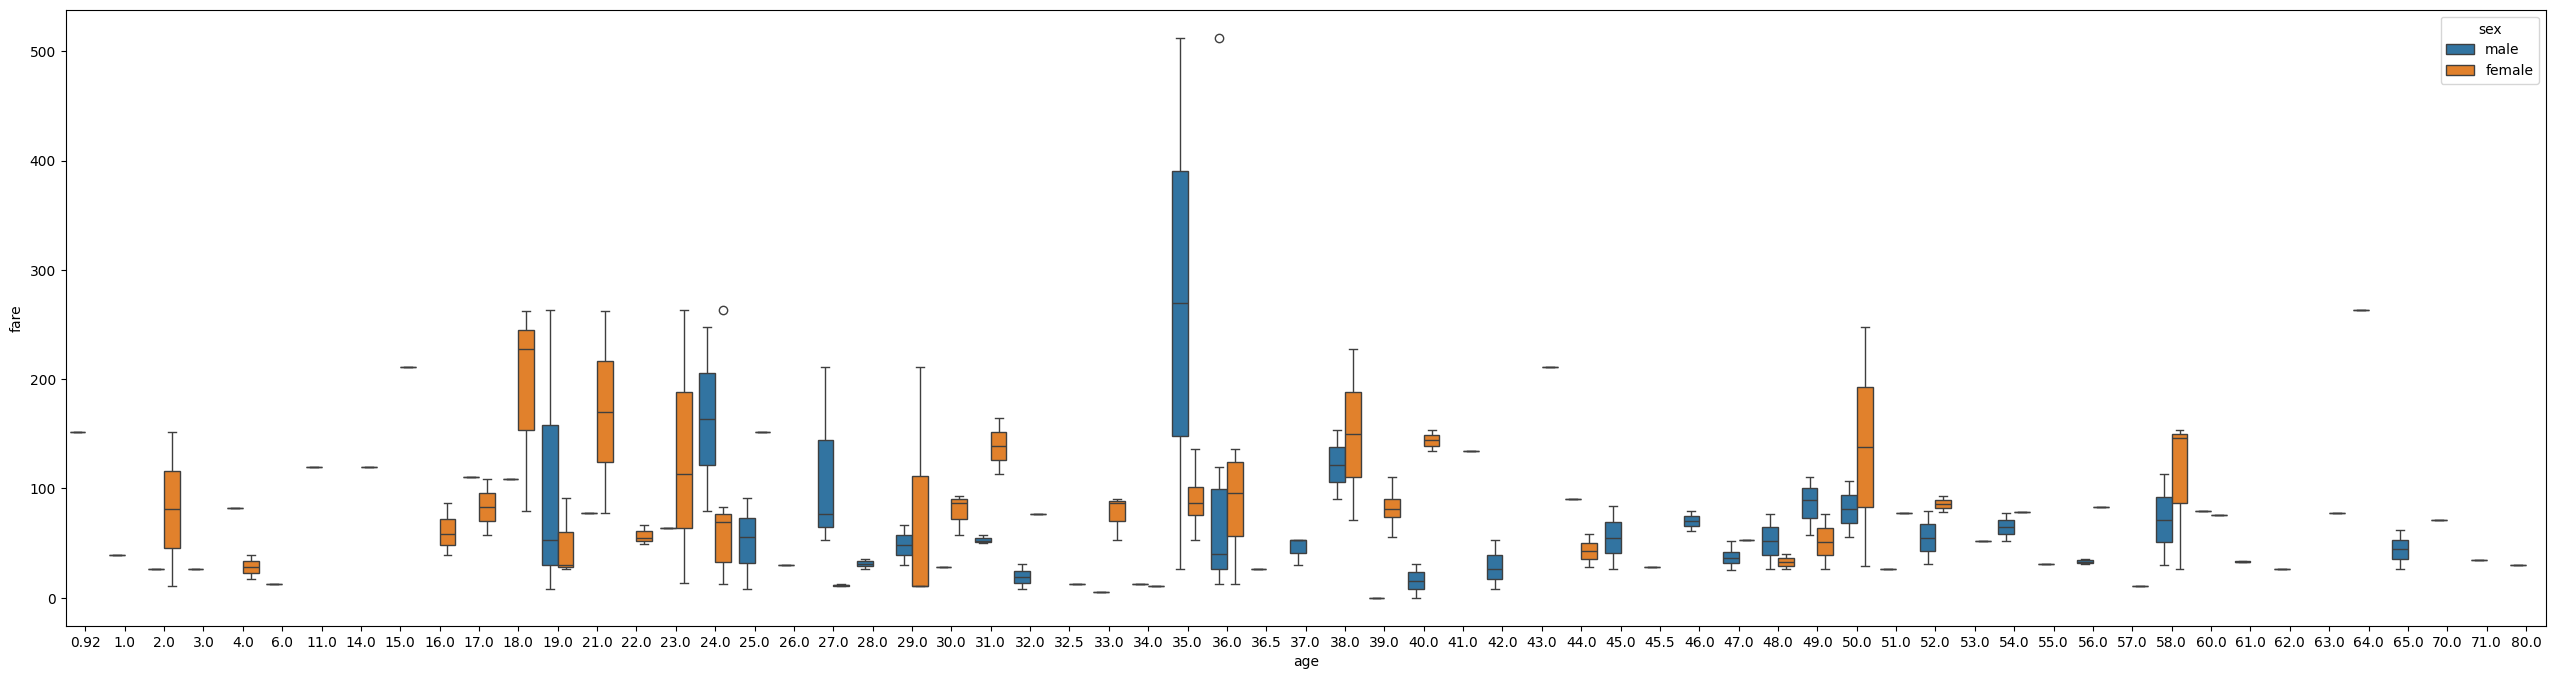

In [103]:
plt.figure(figsize=(32, 8))
sns.boxplot(x="age", y="fare", data=titanic, hue="sex")


## 3. Visualisation de Distributions

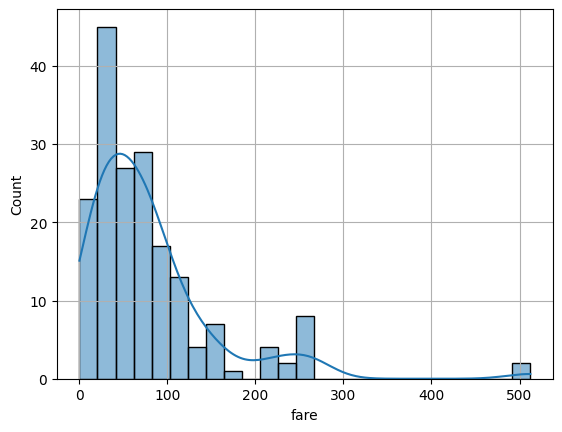

In [104]:
# sns.distplot(titanic['fare']) # Depreciated
sns.histplot(titanic['fare'], kde=True)
plt.grid()
  

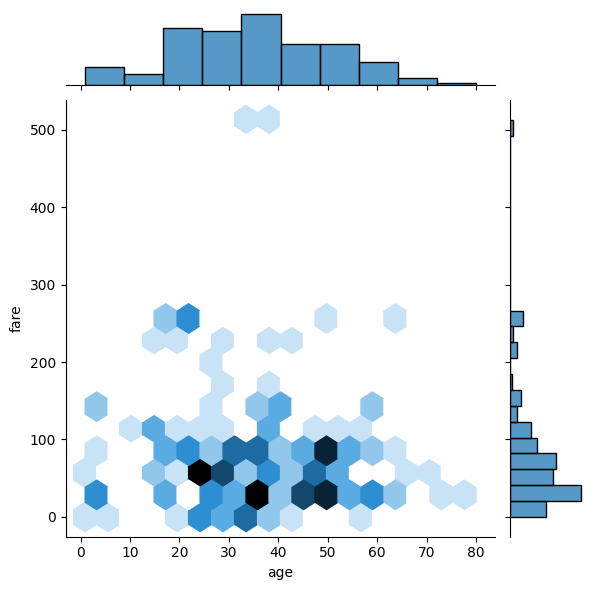

In [105]:
sns.jointplot(x='age', y='fare', data=titanic, kind='hex')
plt.show()


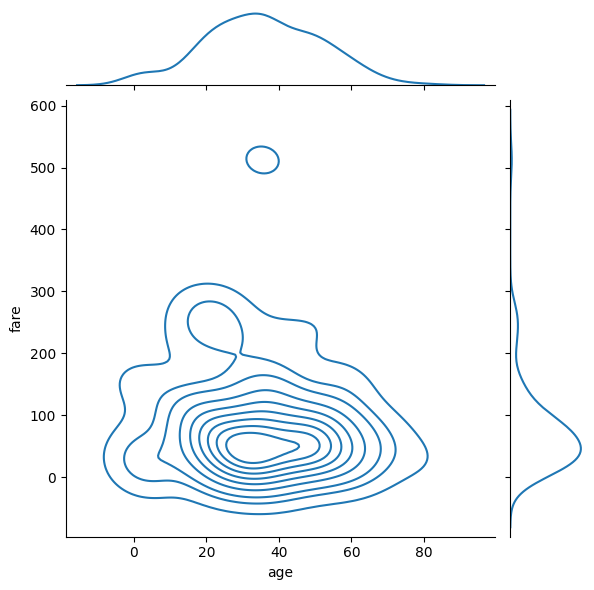

In [106]:
sns.jointplot(x="age", y="fare", data=titanic, kind="kde") # Kernel DEnsity
plt.show()


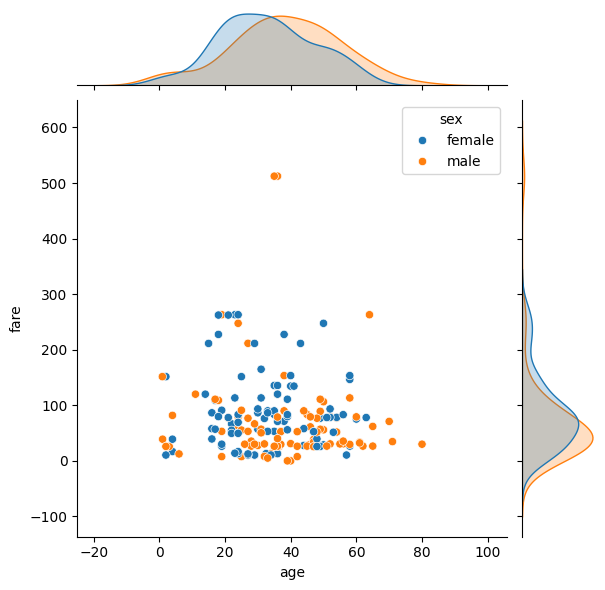

In [107]:
sns.jointplot(x='age', y='fare', data=titanic, hue='sex')
plt.show()


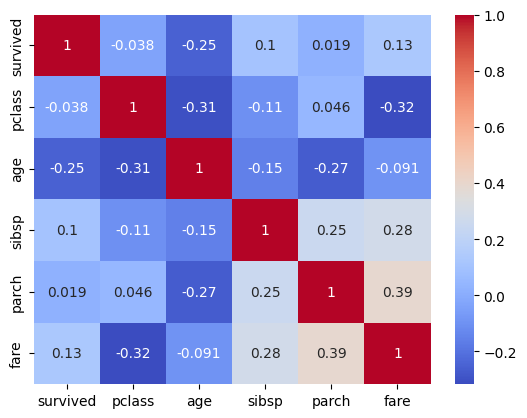

In [108]:
sns.heatmap(titanic.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()


In [109]:
titanic.head(1) # Pour voir les colonne non numériques, nécessaire au heatmap


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
1,1,1,female,38.0,1,0,71.2833,C,C


In [110]:
titanic['deck'].value_counts(dropna=False)


deck
C    51
B    43
D    31
E    30
A    12
F    11
G     4
Name: count, dtype: int64

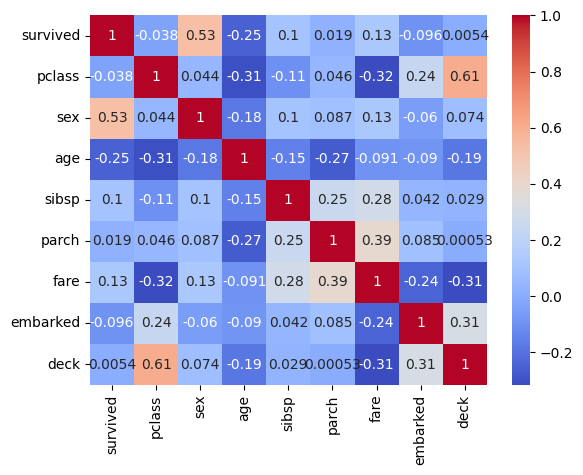

In [113]:
titanic2 = titanic.copy()
titanic2["sex"] = titanic2["sex"].map({"male": 0, "female": 1})
titanic2["embarked"] = titanic2["embarked"].map({"C": 0, "Q": 1, "S": 2})
titanic2["deck"] = titanic2["deck"].map({"C": 0, "Q": 1, "S": 2})
mapping = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6}
titanic2["deck"] = titanic["deck"].map(mapping)
sns.heatmap(titanic2.corr(), annot=True, cmap="coolwarm")
plt.show()


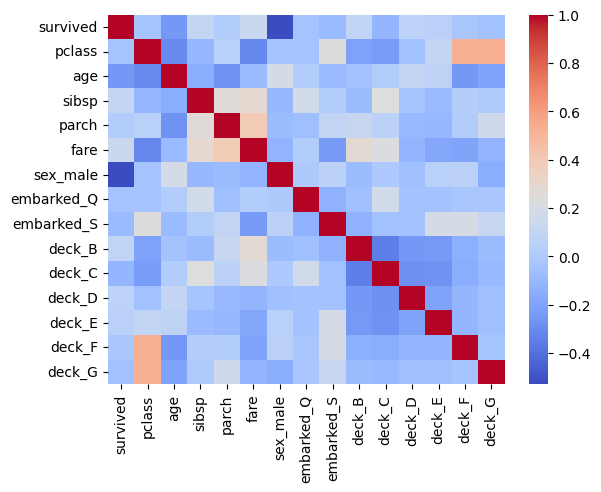

In [ ]:
titanic_encoded = pd.get_dummies(titanic, drop_first=True)

sns.heatmap(titanic_encoded.corr(), cmap="coolwarm")
plt.show()
